M02    36
M01    29
Name: f1, dtype: int64
A    17
B    16
C    16
D    16
Name: f2, dtype: int64
60    12
45    10
25     8
20     7
55     6
35     6
40     6
30     4
50     4
15     2
Name: f3, dtype: int64
Y    26
N    25
?    14
Name: f4, dtype: int64
Y    28
N    23
?    14
Name: f5, dtype: int64
Y    27
N    24
?    14
Name: f6, dtype: int64
+    57
-     8
Name: target, dtype: int64
Training features shape: (40, 6)
Training target shape: (40,)
Test features shape: (11, 6)
Test target shape: (11,)
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'random_state': 15, 'splitter': 'best'}


DecisionTreeClassifier(random_state=15)

Accuracy: 0.818
Precision: 0.450
Recall: 0.818
F1 score: 0.818


[Text(0.5, 0.9285714285714286, 'f3 <= -0.959\ngini = 0.219\nsamples = 40\nvalue = [35, 5]\nclass = 0.0'),
 Text(0.2777777777777778, 0.7857142857142857, 'f4 <= -0.02\ngini = 0.397\nsamples = 11\nvalue = [8, 3]\nclass = 0.0'),
 Text(0.2222222222222222, 0.6428571428571429, 'f3 <= -1.646\ngini = 0.49\nsamples = 7\nvalue = [4, 3]\nclass = 0.0'),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = 0.0'),
 Text(0.2777777777777778, 0.5, 'f3 <= -1.303\ngini = 0.5\nsamples = 6\nvalue = [3, 3]\nclass = 0.0'),
 Text(0.16666666666666666, 0.35714285714285715, 'f2 <= -0.902\ngini = 0.444\nsamples = 3\nvalue = [1, 2]\nclass = 1.0'),
 Text(0.1111111111111111, 0.21428571428571427, 'f6 <= -0.059\ngini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = 0.0'),
 Text(0.05555555555555555, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = 1.0'),
 Text(0.16666666666666666, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = 0.0'),
 Text(0.222222222

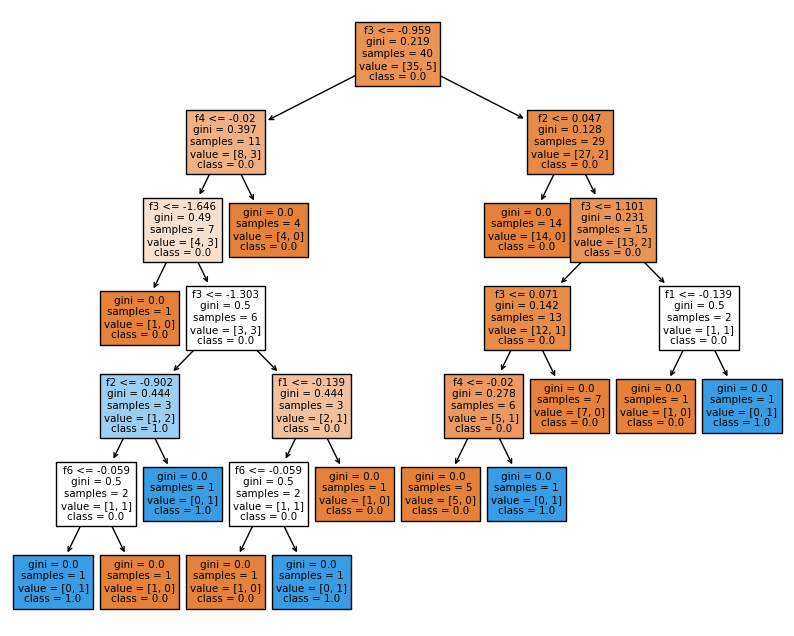

DecisionTreeClassifier(max_depth=2, random_state=15)

Accuracy: 0.909
Precision: 0.955
Recall: 0.909
F1 score: 0.866


GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(max_depth=2, random_state=15),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8]})

Best hyperparameters: {'max_depth': 2, 'min_samples_split': 6}
Best score: 0.875


DecisionTreeClassifier(max_depth=2, min_samples_split=6, random_state=15)

Accuracy on test data: 0.9090909090909091


<Figure size 1000x800 with 0 Axes>

[Text(0.5, 0.8333333333333334, 'f3 <= -0.959\ngini = 0.219\nsamples = 40\nvalue = [35, 5]\nclass = 0.0'),
 Text(0.25, 0.5, 'f4 <= -0.02\ngini = 0.397\nsamples = 11\nvalue = [8, 3]\nclass = 0.0'),
 Text(0.125, 0.16666666666666666, 'gini = 0.49\nsamples = 7\nvalue = [4, 3]\nclass = 0.0'),
 Text(0.375, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]\nclass = 0.0'),
 Text(0.75, 0.5, 'f2 <= 0.047\ngini = 0.128\nsamples = 29\nvalue = [27, 2]\nclass = 0.0'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]\nclass = 0.0'),
 Text(0.875, 0.16666666666666666, 'gini = 0.231\nsamples = 15\nvalue = [13, 2]\nclass = 0.0')]

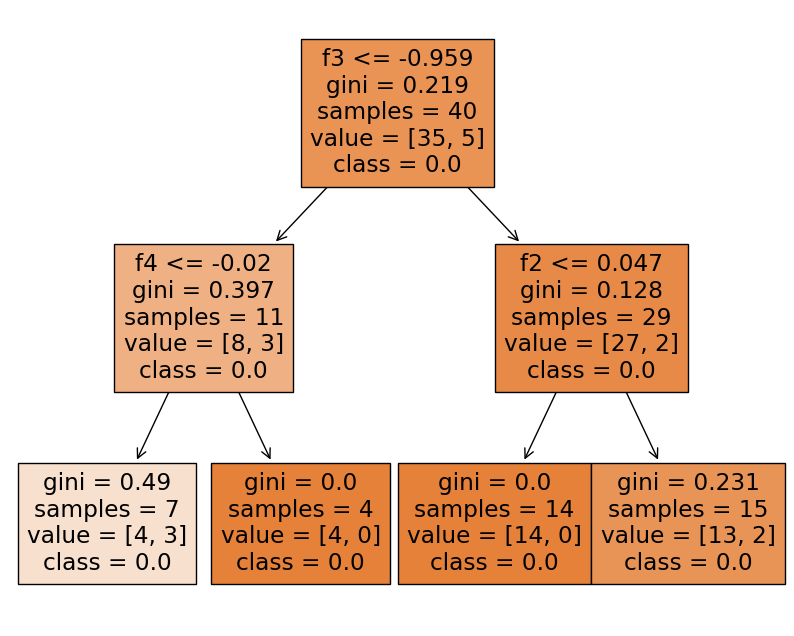

Accuracy: 0.909
Precision: 0.955
Recall: 0.909
F1 score: 0.866


In [56]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#____________________________ part a ______________________________#
import pandas as pd

exam_data = pd.read_csv('exam-scores.csv', sep=',')
#exam_data.head(20)

#____________________________ part a ______________________________#
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

exam_data=exam_data.dropna()

for attr in list(exam_data.columns):
    print(exam_data[attr].value_counts())
    
exam_data = exam_data[~exam_data[['f4', 'f5', 'f6']].apply(lambda x: x.str.contains('?', regex=False)).any(axis=1)]
#exam_data.to_csv('my_data.csv', index=False)

enc1=OrdinalEncoder()
for attr in list(exam_data.columns):
    if attr != 'f3':
        exam_data[[attr]] = enc1.fit_transform(exam_data[[attr]])

#for col in exam_data.columns:
#    exam_data[col] = pd.to_numeric(exam_data[col], errors='coerce')
exam_data=exam_data.astype(float)
#print(exam_data.dtypes)

# selecting the features and target variable
features = exam_data[['f1', 'f2', 'f3', 'f4', 'f5', 'f6']]
target = exam_data['target']

# scaling the numeric features using StandardScaler
scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

#____________________________ part b ______________________________#
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, target, test_size=0.2, random_state=42, stratify=target)

print('Training features shape:', X_train.shape)
print('Training target shape:', y_train.shape)
print('Test features shape:', X_test.shape)
print('Test target shape:', y_test.shape)

#____________________________ part c ______________________________#
from sklearn.tree import DecisionTreeClassifier

# initializing a decision tree classifier with default parameters
clf = DecisionTreeClassifier(random_state=15)

# printing the parameters of the decision tree classifier
print(clf.get_params())

#____________________________ part d ______________________________#

clf.fit(X_train, y_train)

#____________________________ part e ______________________________#
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy: {:.3f}".format(accuracy))
print("Precision: {:.3f}".format(precision))
print("Recall: {:.3f}".format(recall))
print("F1 score: {:.3f}".format(f1))

#____________________________ part f ______________________________#
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

#features.columns = features.columns.fillna('NaN').astype(str)
_=plt.figure(figsize=(10, 8))
plot_tree(clf, filled=True, feature_names=features.columns, class_names=target.unique().astype(str))
plt.show()
#____________________________ part g ______________________________#

clf = DecisionTreeClassifier(max_depth=2, min_samples_split=2, random_state=15)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy: {:.3f}".format(accuracy))
print("Precision: {:.3f}".format(precision))
print("Recall: {:.3f}".format(recall))
print("F1 score: {:.3f}".format(f1))

#____________________________ part h ______________________________#
from sklearn.model_selection import GridSearchCV

# defining the hyperparameter grid
param_grid = {'max_depth': [2, 3, 4, 5, 6, 7, 8], 'min_samples_split': [2, 3, 4, 5, 6, 7, 8]}

# performming grid search with cross-validation
grid_search = GridSearchCV(clf, param_grid=param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# getting the best hyperparameters and the best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print('Best hyperparameters:', best_params)
print('Best score:', best_score)

# initializing a decision tree classifier object with the best hyperparameters
clf = DecisionTreeClassifier(max_depth=best_params['max_depth'], min_samples_split=best_params['min_samples_split'], random_state=15)

# fitting the classifier to the training data
clf.fit(X_train, y_train)

# evaluating the performance of the classifier on the test data
accuracy = clf.score(X_test, y_test)
print('Accuracy on test data:', accuracy)

# visualize the decision tree
plt.figure(figsize=(10, 8))
plot_tree(clf, filled=True, feature_names=features.columns, class_names=target.unique().astype(str))
plt.show()

#____________________________ part i ______________________________#

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy: {:.3f}".format(accuracy))
print("Precision: {:.3f}".format(precision))
print("Recall: {:.3f}".format(recall))
print("F1 score: {:.3f}".format(f1))
